# Quickstart

## Installation

Install PyStemFinder from GitHub with pip:

```bash
pip install git+https://github.com/CahanLab/PyStemFinder.git
```

To run this notebook, clone the repository, create a conda environment with the dependencies listed in `environment.yml` (in the repository root), and install PyStemFinder into it:

```bash
git clone https://github.com/CahanLab/PyStemFinder.git
cd PyStemFinder
conda env create -f environment.yml
conda activate pystemfinder
pip install -e .
```

## Setup
In Python, import some packages that we need

In [1]:
import pystemfinder as psf

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

## Generating toy data sets

As stemFinder metrics examine stochasticity in gene expression it is helpful to be able to generate toy data sets.

Generate toy data set with following parameters:

- 300 cells x 50 genes
- 3 different populations
- overall dropout rate = 25%
- population specific dropout = 25%, 40%, 60%
-  mean expression difference of stochastic genes by population = 0, 2, 4

In [2]:
adata = psf.simulate_data(dropout_rate = 0.25, stochastic_dropout_by_population = (0.25, 0.4, 0.6), stochastic_expression_diff=(0, 2, 4))
adata

AnnData object with n_obs × n_vars = 300 × 50
    layers: None (.X)

## Dimension reduction

There is no need to normalize this syntheric data. Cluster the data, after running PCA (usually we would exclude stochastic genes, which are var_names[40:45] by default, but in this case, since we are not computing HVG, just keep them in)
kNN
Leiden cluster
Plot

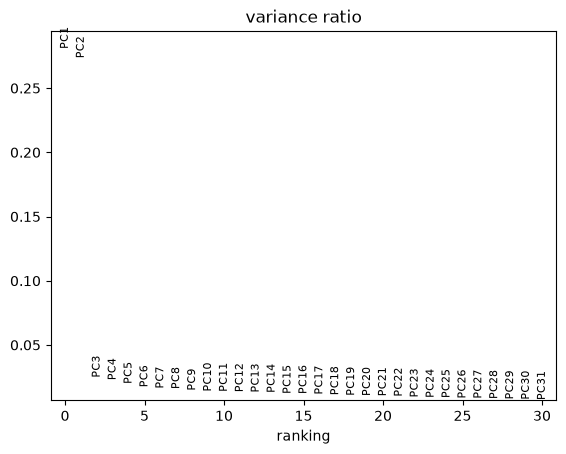

In [3]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

## Cluster the cells

First run kNN, the Leiden cluster, and plot the embedded cells colored by cluster. Note that we set k = log(number of cells).

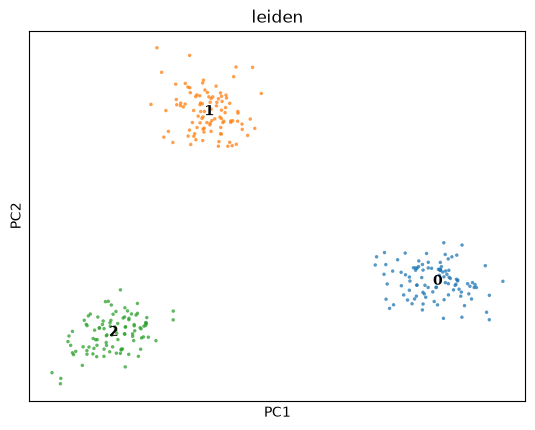

In [4]:
%matplotlib inline
npcs = 2
n_neighbors = int(np.round(np.log(adata.n_obs)))
sc.pp.neighbors(adata, n_neighbors=n_neighbors, n_pcs=npcs)
sc.tl.leiden(adata, .1, flavor='igraph', n_iterations=2, directed=False)
sc.pl.pca(adata, color=['leiden'], alpha=.75, s=25, legend_loc='on data')

## Visual gene expression
Plot heatmaps of the data, grouped by leiden cluster. First plot counts data. Then plot binarized data, which is what the stemFinder computation is based on.

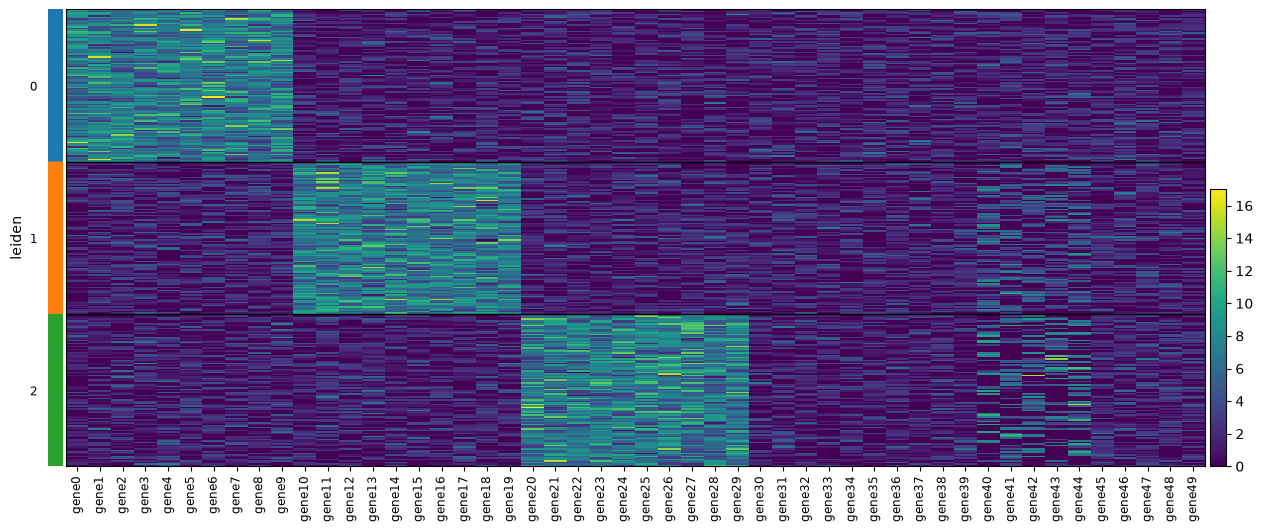

In [5]:
sc.pl.heatmap(adata, var_names=adata.var_names, groupby='leiden')

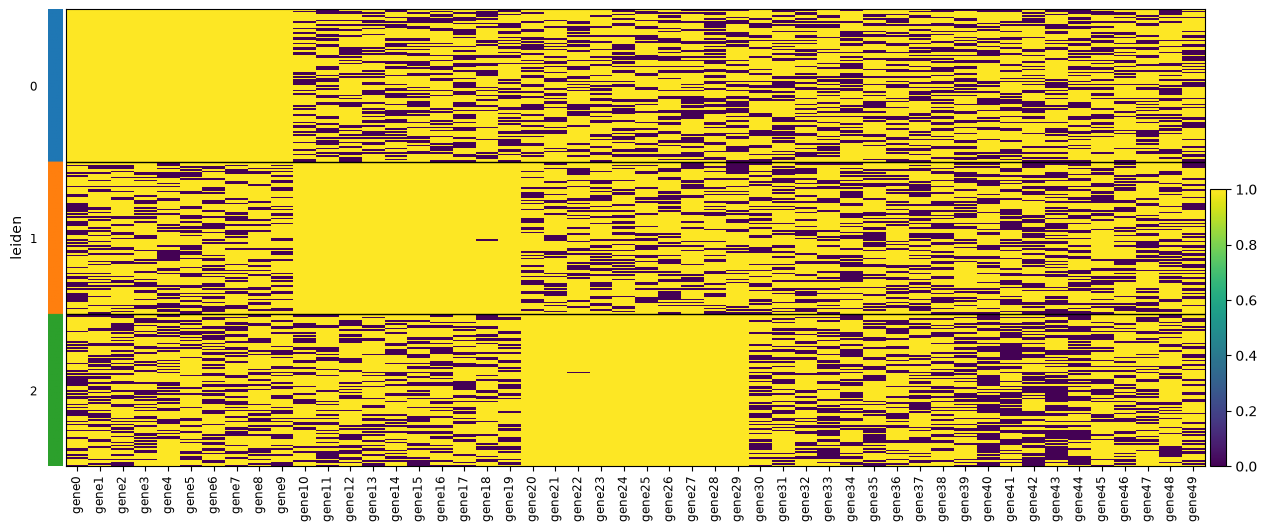

In [6]:
thresh = 0.0
adata.layers['binary'] = psf.binarize(adata.X, thresh)
sc.pl.heatmap(adata, var_names=adata.var_names, groupby='leiden', layer='binary')

## stemFinder and diffOmeter

Based on the heatmaps above, try to guess which clusters will have the highest stemFinder and diffOmeter scores.

`stemfinder` adds two columns to `.obs`, matching the R package:

- `stemfinder_raw`: heterogeneity of the marker genes among each cell's neighbors; higher means less differentiated.
- `stemfinder`: `1 - stemfinder_raw / max(stemfinder_raw)`, oriented like pseudotime (lower means less differentiated).

`diffometer` is the average Gini impurity of the genes across each cell's neighborhood (including the cell itself); higher means less differentiated.

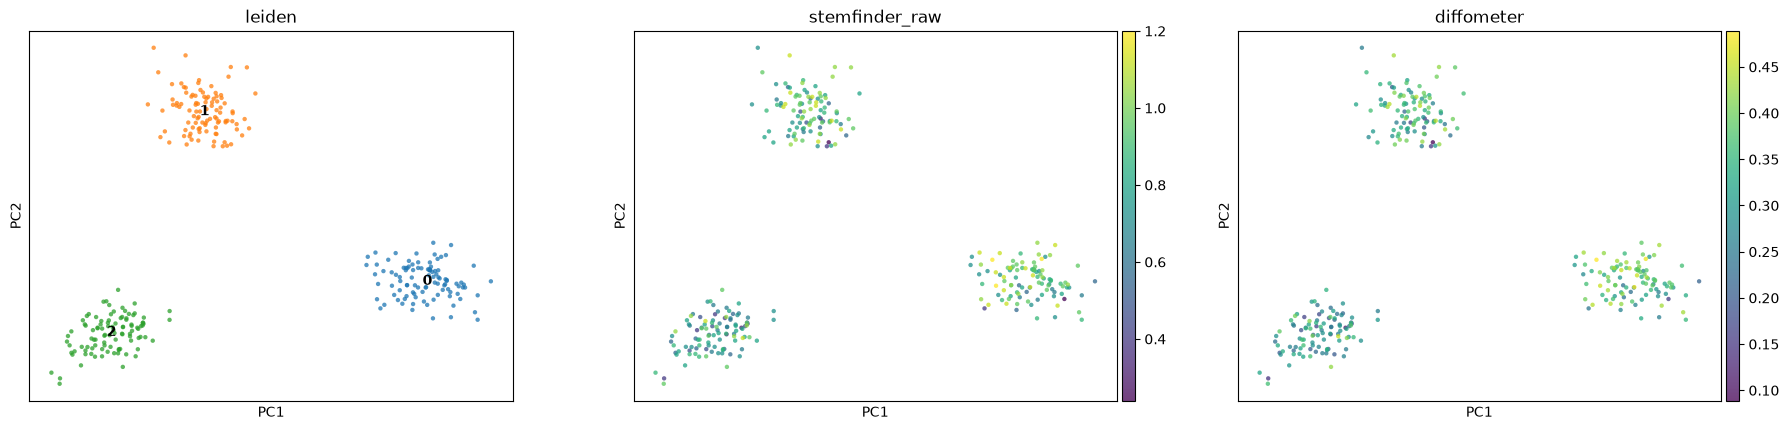

In [7]:
# these are the 'stochastic' genes, which would be cell cycle related genes for real data
geneset_a = adata.var_names[40:45].tolist()
psf.stemfinder(adata, geneset_a, threshold=thresh)
psf.diffometer(adata, geneset_a, thresh)

sc.pl.pca(adata, color=['leiden', 'stemfinder_raw', 'diffometer'], alpha=.75, s=40, legend_loc='on data')


## Visualize scores by cluster
Violin plot to compare score distributions between clusters
Sort the violins by median score

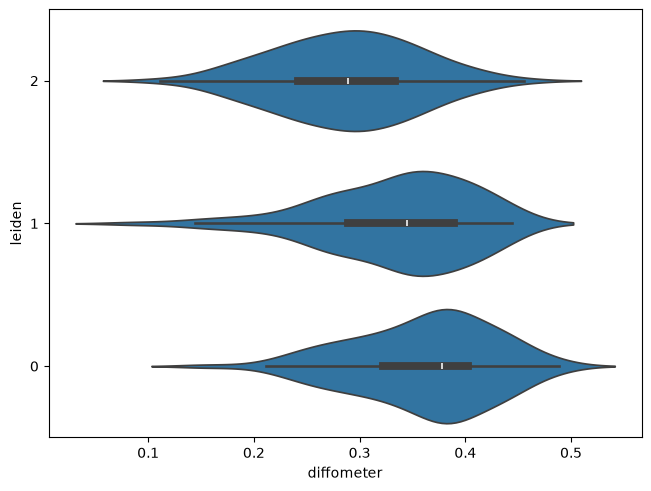

In [8]:
potScore = 'diffometer'
catName = "leiden"
group_means = adata.obs.groupby(catName)[potScore].median()
sorted_groups = group_means.sort_values().index.tolist()
df = adata.obs[[catName, potScore]]

plt.subplots(layout="constrained")
sns.violinplot(y=catName, x=potScore, data=df, order=sorted_groups, orient='h') 
plt.show()

The high diffOmeter score of cluster 0 (average Gini impurity of genes 40-45 across each cell's neighborhood) reflects the greater stochasticity of expression of genes 40-45, which implies a relatively undifferentiated state. Cluster 0 is made of the cells whose dropout rate for these genes (25%) matches the background dropout rate; clusters 1 and 2 have 40% and 60% dropout.

How does this compare to stemFinder?

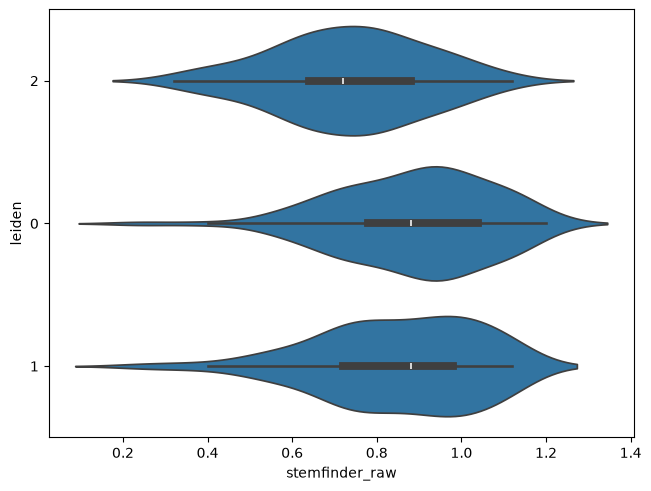

In [9]:
potScore = 'stemfinder_raw'
catName = "leiden"
group_means = adata.obs.groupby(catName)[potScore].median()
sorted_groups = group_means.sort_values().index.tolist()
df = adata.obs[[catName, potScore]]

plt.subplots(layout="constrained")
sns.violinplot(y=catName, x=potScore, data=df, order=sorted_groups, orient='h') 
plt.show()


The two metrics are highly correlated, and stemFinder separates clusters 0 and 1 less clearly than diffOmeter. The correlation is expected: p(1 - p) is the same whether p counts the neighbors that match the cell or those that don't, so `stemfinder_raw` is half the summed Gini impurity of the markers across each cell's neighbors. `diffometer` averages the impurity instead, and by default also counts the cell itself. Without the cell, the two are proportional:

In [10]:
psf.diffometer(adata, geneset_a, thresh, include_self=False)
np.allclose(adata.obs['diffometer'], 2 * adata.obs['stemfinder_raw'] / len(geneset_a))

True

## Going further
The toy data simulator can be used to explore how these stemness metrics behave across different parameter choices. For example, in what situations does gene standardization matter, and does it have surprising results?